# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Импорты, seed и устройство


In [1]:
import os
import json
import copy
import csv
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Device: {device}")
print(f"Seed: {SEED}")


PyTorch: 2.10.0+cpu
Torchvision: 0.25.0+cpu
Device: cpu
Seed: 42


## 2. Данные и DataLoader

Выбран датасет **EMNIST Balanced** (вариант B) — 47 классов (цифры + строчные и прописные латинские буквы), 28×28 grayscale.
Датасет сложнее MNIST за счёт большего числа классов и схожести некоторых символов.


In [2]:
DATASET_NAME = "EMNIST"
NUM_CLASSES = 47
INPUT_DIM = 784

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

print(f"Датасет: {DATASET_NAME} (split=balanced)")
print(f"Классов: {NUM_CLASSES}, Input dim: {INPUT_DIM}")

# --- Train / Val split (80/20) ---
n_train = int(0.8 * len(full_train_dataset))
n_val = len(full_train_dataset) - n_train
train_dataset, val_dataset = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# --- DataLoaders ---
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Sanity check ---
x_batch, y_batch = next(iter(train_loader))
print(f"x_batch shape: {x_batch.shape}, dtype: {x_batch.dtype}")
print(f"y_batch shape: {y_batch.shape}, dtype: {y_batch.dtype}")
print(f"x range: [{x_batch.min():.2f}, {x_batch.max():.2f}]")
print(f"Labels sample: {y_batch[:10].tolist()}")


100%|██████████| 562M/562M [01:19<00:00, 7.04MB/s] 


Датасет: EMNIST (split=balanced)
Классов: 47, Input dim: 784
Train: 90240, Val: 22560, Test: 18800
x_batch shape: torch.Size([128, 1, 28, 28]), dtype: torch.float32
y_batch shape: torch.Size([128]), dtype: torch.int64
x range: [-1.00, 1.00]
Labels sample: [32, 3, 36, 29, 28, 23, 39, 2, 9, 10]


## 3. Модели MLP


In [3]:
class MLPBase(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[512, 256], num_classes=47):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MLPDropout(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[512, 256], num_classes=47, p=0.3):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MLPBatchNorm(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[512, 256], num_classes=47):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


print("Модели определены: MLPBase, MLPDropout, MLPBatchNorm")


Модели определены: MLPBase, MLPDropout, MLPBatchNorm


## 4. Цикл обучения и оценки


In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


def run_experiment(model, train_loader, val_loader, criterion, optimizer,
                   device, max_epochs=25, early_stopping=False, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
                  f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}")

        if early_stopping and epochs_no_improve >= patience:
            print(f"  -> EarlyStopping на эпохе {epoch} (patience={patience})")
            break

    epochs_trained = len(history['train_loss'])
    best_val_loss = min(history['val_loss'])
    return history, best_val_acc, best_val_loss, best_state, epochs_trained


print("Функции обучения определены.")


Функции обучения определены.


## 5. Часть A (S08): регуляризация (E1–E4)


In [5]:
MAX_EPOCHS = 25
LR = 1e-3
criterion = nn.CrossEntropyLoss()
results = {}

# ---- E1: Base ----
print("=" * 50)
print("E1: Base MLP (без регуляризации)")
print("=" * 50)
torch.manual_seed(SEED)
model_e1 = MLPBase(INPUT_DIM, [512, 256], NUM_CLASSES).to(device)
opt_e1 = optim.Adam(model_e1.parameters(), lr=LR)
hist_e1, best_va_e1, best_vl_e1, state_e1, ep_e1 = run_experiment(
    model_e1, train_loader, val_loader, criterion, opt_e1, device, max_epochs=MAX_EPOCHS
)
results['E1'] = {'history': hist_e1, 'best_val_acc': best_va_e1,
                 'best_val_loss': best_vl_e1, 'epochs': ep_e1}
print(f"  Best val_acc: {best_va_e1:.4f}\n")


E1: Base MLP (без регуляризации)
  Epoch   1 | train_loss=1.1262 train_acc=0.6680 | val_loss=0.7430 val_acc=0.7673
  Epoch   5 | train_loss=0.4207 train_acc=0.8517 | val_loss=0.5035 val_acc=0.8333
  Epoch  10 | train_loss=0.3023 train_acc=0.8840 | val_loss=0.4879 val_acc=0.8446
  Epoch  15 | train_loss=0.2379 train_acc=0.9038 | val_loss=0.5659 val_acc=0.8347
  Epoch  20 | train_loss=0.2021 train_acc=0.9160 | val_loss=0.6481 val_acc=0.8361
  Epoch  25 | train_loss=0.1744 train_acc=0.9276 | val_loss=0.7192 val_acc=0.8375
  Best val_acc: 0.8453



In [6]:
# ---- E2: Dropout (p=0.3) ----
print("=" * 50)
print("E2: MLP + Dropout(p=0.3)")
print("=" * 50)
torch.manual_seed(SEED)
model_e2 = MLPDropout(INPUT_DIM, [512, 256], NUM_CLASSES, p=0.3).to(device)
opt_e2 = optim.Adam(model_e2.parameters(), lr=LR)
hist_e2, best_va_e2, best_vl_e2, state_e2, ep_e2 = run_experiment(
    model_e2, train_loader, val_loader, criterion, opt_e2, device, max_epochs=MAX_EPOCHS
)
results['E2'] = {'history': hist_e2, 'best_val_acc': best_va_e2,
                 'best_val_loss': best_vl_e2, 'epochs': ep_e2}
print(f"  Best val_acc: {best_va_e2:.4f}\n")


E2: MLP + Dropout(p=0.3)
  Epoch   1 | train_loss=1.3822 train_acc=0.5951 | val_loss=0.7839 val_acc=0.7610
  Epoch   5 | train_loss=0.6579 train_acc=0.7835 | val_loss=0.5236 val_acc=0.8259
  Epoch  10 | train_loss=0.5682 train_acc=0.8062 | val_loss=0.4772 val_acc=0.8426
  Epoch  15 | train_loss=0.5261 train_acc=0.8180 | val_loss=0.4734 val_acc=0.8411
  Epoch  20 | train_loss=0.5067 train_acc=0.8231 | val_loss=0.4470 val_acc=0.8493
  Epoch  25 | train_loss=0.4909 train_acc=0.8265 | val_loss=0.4566 val_acc=0.8464
  Best val_acc: 0.8493



In [7]:
# ---- E3: BatchNorm ----
print("=" * 50)
print("E3: MLP + BatchNorm")
print("=" * 50)
torch.manual_seed(SEED)
model_e3 = MLPBatchNorm(INPUT_DIM, [512, 256], NUM_CLASSES).to(device)
opt_e3 = optim.Adam(model_e3.parameters(), lr=LR)
hist_e3, best_va_e3, best_vl_e3, state_e3, ep_e3 = run_experiment(
    model_e3, train_loader, val_loader, criterion, opt_e3, device, max_epochs=MAX_EPOCHS
)
results['E3'] = {'history': hist_e3, 'best_val_acc': best_va_e3,
                 'best_val_loss': best_vl_e3, 'epochs': ep_e3}
print(f"  Best val_acc: {best_va_e3:.4f}\n")


E3: MLP + BatchNorm
  Epoch   1 | train_loss=0.8500 train_acc=0.7498 | val_loss=0.5611 val_acc=0.8184
  Epoch   5 | train_loss=0.3261 train_acc=0.8799 | val_loss=0.4494 val_acc=0.8465
  Epoch  10 | train_loss=0.2224 train_acc=0.9117 | val_loss=0.4717 val_acc=0.8489
  Epoch  15 | train_loss=0.1684 train_acc=0.9305 | val_loss=0.5345 val_acc=0.8438
  Epoch  20 | train_loss=0.1364 train_acc=0.9442 | val_loss=0.5898 val_acc=0.8471
  Epoch  25 | train_loss=0.1127 train_acc=0.9537 | val_loss=0.6583 val_acc=0.8434
  Best val_acc: 0.8518



In [8]:
# ---- E4: лучший из E2/E3 + EarlyStopping ----
print("=" * 50)
if best_va_e2 >= best_va_e3:
    best_reg = "Dropout"
    print(f"E4: лучший — Dropout (E2={best_va_e2:.4f} >= E3={best_va_e3:.4f})")
    E4ModelClass = MLPDropout
    e4_kwargs = dict(input_dim=INPUT_DIM, hidden_dims=[512, 256], num_classes=NUM_CLASSES, p=0.3)
else:
    best_reg = "BatchNorm"
    print(f"E4: лучший — BatchNorm (E3={best_va_e3:.4f} > E2={best_va_e2:.4f})")
    E4ModelClass = MLPBatchNorm
    e4_kwargs = dict(input_dim=INPUT_DIM, hidden_dims=[512, 256], num_classes=NUM_CLASSES)
print("=" * 50)

torch.manual_seed(SEED)
model_e4 = E4ModelClass(**e4_kwargs).to(device)
opt_e4 = optim.Adam(model_e4.parameters(), lr=LR)
hist_e4, best_va_e4, best_vl_e4, state_e4, ep_e4 = run_experiment(
    model_e4, train_loader, val_loader, criterion, opt_e4, device,
    max_epochs=50, early_stopping=True, patience=5
)
results['E4'] = {'history': hist_e4, 'best_val_acc': best_va_e4,
                 'best_val_loss': best_vl_e4, 'epochs': ep_e4,
                 'model_class': E4ModelClass.__name__, 'regularizer': best_reg}
print(f"  Best val_acc: {best_va_e4:.4f}, epochs: {ep_e4}\n")


E4: лучший — BatchNorm (E3=0.8518 > E2=0.8493)
  Epoch   1 | train_loss=0.8500 train_acc=0.7498 | val_loss=0.5611 val_acc=0.8184
  Epoch   5 | train_loss=0.3261 train_acc=0.8799 | val_loss=0.4494 val_acc=0.8465
  Epoch  10 | train_loss=0.2224 train_acc=0.9117 | val_loss=0.4717 val_acc=0.8489
  -> EarlyStopping на эпохе 14 (patience=5)
  Best val_acc: 0.8511, epochs: 14



### Финальная оценка лучшей модели (E4) на test


In [9]:
model_e4.load_state_dict(state_e4)
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"E4 Test Accuracy: {test_acc:.4f}")
print(f"E4 Test Loss:     {test_loss:.4f}")


E4 Test Accuracy: 0.8480
E4 Test Loss:     0.4939


## 6. Часть B (S09): LR, оптимизаторы, weight decay (O1–O3)

Архитектура та же, что в E4.


In [10]:
# ---- O1: LR слишком большой ----
print("=" * 50)
print("O1: Adam, lr=0.1 (слишком большой)")
print("=" * 50)
torch.manual_seed(SEED)
model_o1 = E4ModelClass(**e4_kwargs).to(device)
opt_o1 = optim.Adam(model_o1.parameters(), lr=0.1)
hist_o1, best_va_o1, best_vl_o1, _, ep_o1 = run_experiment(
    model_o1, train_loader, val_loader, criterion, opt_o1, device, max_epochs=8
)
results['O1'] = {'history': hist_o1, 'best_val_acc': best_va_o1,
                 'best_val_loss': best_vl_o1, 'epochs': ep_o1}
print(f"  Best val_acc: {best_va_o1:.4f}\n")


O1: Adam, lr=0.1 (слишком большой)
  Epoch   1 | train_loss=1.1222 train_acc=0.6678 | val_loss=0.7934 val_acc=0.7533
  Epoch   5 | train_loss=0.5976 train_acc=0.8012 | val_loss=0.6075 val_acc=0.8067
  Best val_acc: 0.8067



In [11]:
# ---- O2: LR слишком маленький ----
print("=" * 50)
print("O2: Adam, lr=1e-6 (слишком маленький)")
print("=" * 50)
torch.manual_seed(SEED)
model_o2 = E4ModelClass(**e4_kwargs).to(device)
opt_o2 = optim.Adam(model_o2.parameters(), lr=1e-6)
hist_o2, best_va_o2, best_vl_o2, _, ep_o2 = run_experiment(
    model_o2, train_loader, val_loader, criterion, opt_o2, device, max_epochs=8
)
results['O2'] = {'history': hist_o2, 'best_val_acc': best_va_o2,
                 'best_val_loss': best_vl_o2, 'epochs': ep_o2}
print(f"  Best val_acc: {best_va_o2:.4f}\n")


O2: Adam, lr=1e-6 (слишком маленький)
  Epoch   1 | train_loss=3.8145 train_acc=0.0427 | val_loss=3.7153 val_acc=0.0693
  Epoch   5 | train_loss=3.1722 train_acc=0.3045 | val_loss=3.1090 val_acc=0.3306
  Best val_acc: 0.4320



In [12]:
# ---- O3: SGD + momentum + weight_decay ----
print("=" * 50)
print("O3: SGD, lr=0.01, momentum=0.9, weight_decay=1e-4")
print("=" * 50)
torch.manual_seed(SEED)
model_o3 = E4ModelClass(**e4_kwargs).to(device)
opt_o3 = optim.SGD(model_o3.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
hist_o3, best_va_o3, best_vl_o3, _, ep_o3 = run_experiment(
    model_o3, train_loader, val_loader, criterion, opt_o3, device, max_epochs=15
)
results['O3'] = {'history': hist_o3, 'best_val_acc': best_va_o3,
                 'best_val_loss': best_vl_o3, 'epochs': ep_o3}
print(f"  Best val_acc: {best_va_o3:.4f}\n")


O3: SGD, lr=0.01, momentum=0.9, weight_decay=1e-4
  Epoch   1 | train_loss=0.9967 train_acc=0.7199 | val_loss=0.6156 val_acc=0.8067
  Epoch   5 | train_loss=0.3591 train_acc=0.8728 | val_loss=0.4593 val_acc=0.8441
  Epoch  10 | train_loss=0.2519 train_acc=0.9059 | val_loss=0.4596 val_acc=0.8465
  Epoch  15 | train_loss=0.1948 train_acc=0.9251 | val_loss=0.4839 val_acc=0.8420
  Best val_acc: 0.8494



## 7. Графики


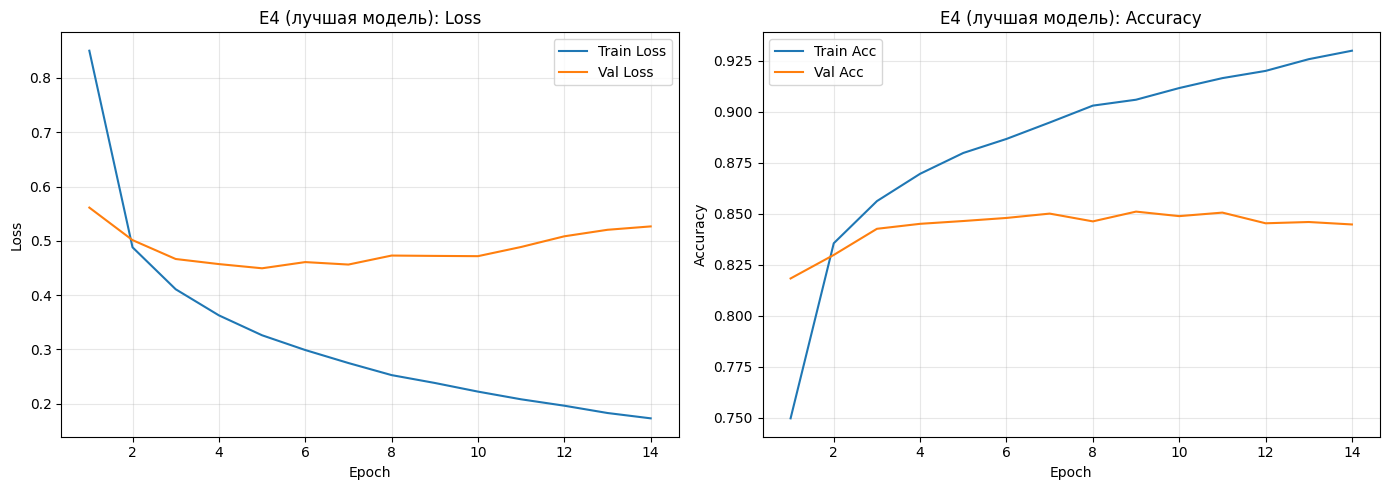

Saved: artifacts/figures/curves_best.png


In [13]:
os.makedirs('artifacts/figures', exist_ok=True)

# --- curves_best.png (E4) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_range = range(1, len(hist_e4['train_loss']) + 1)

axes[0].plot(ep_range, hist_e4['train_loss'], label='Train Loss')
axes[0].plot(ep_range, hist_e4['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('E4 (лучшая модель): Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, hist_e4['train_acc'], label='Train Acc')
axes[1].plot(ep_range, hist_e4['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('E4 (лучшая модель): Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150)
plt.show()
print("Saved: artifacts/figures/curves_best.png")


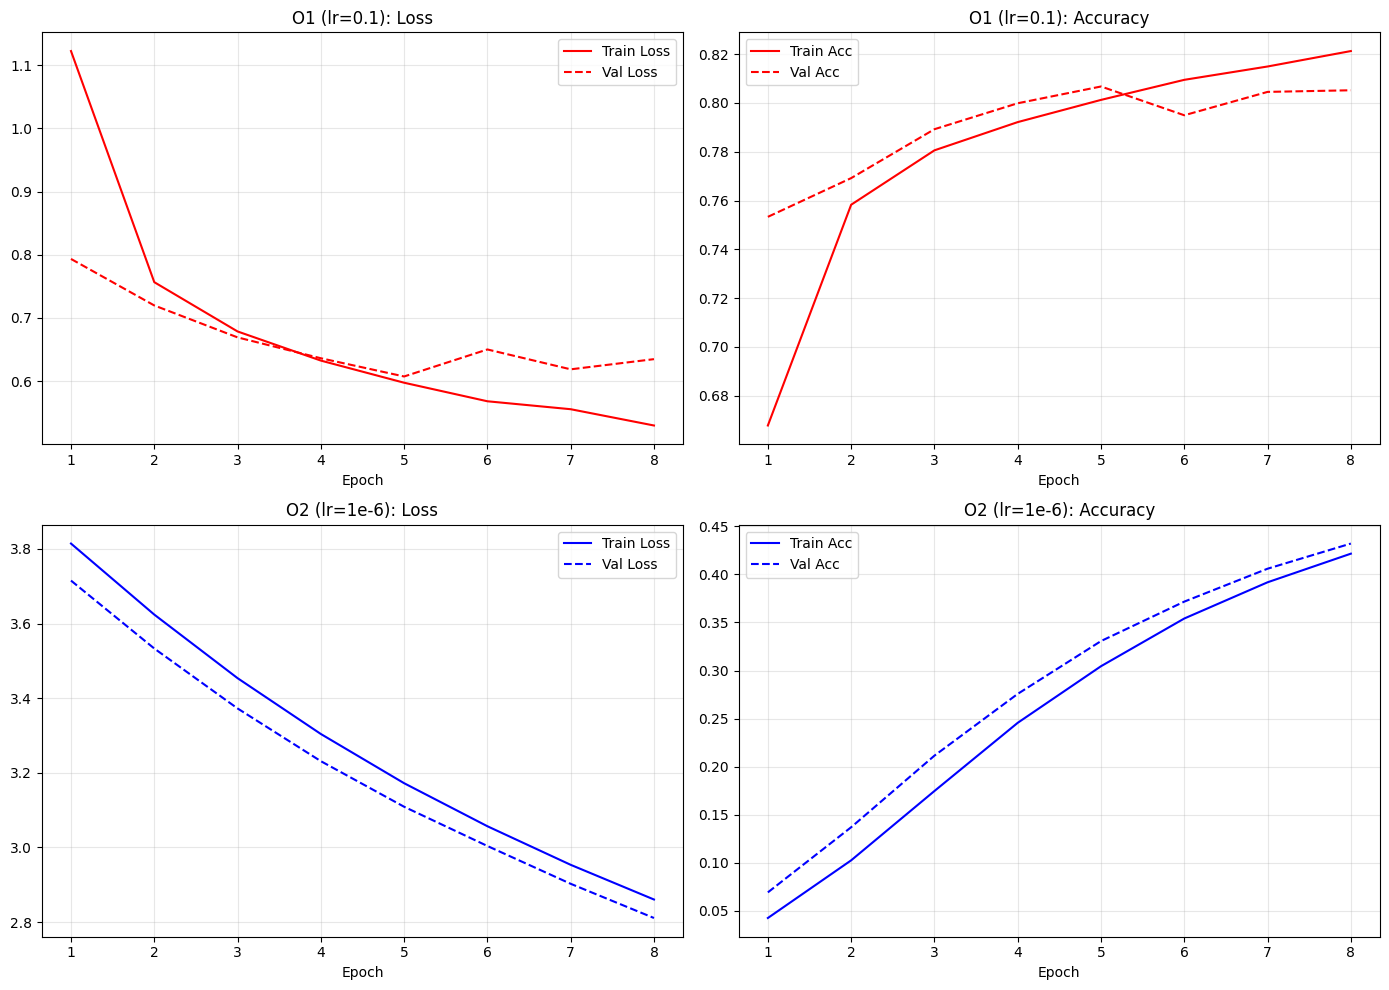

Saved: artifacts/figures/curves_lr_extremes.png


In [14]:
# --- curves_lr_extremes.png (O1, O2) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

r1 = range(1, len(hist_o1['train_loss']) + 1)
r2 = range(1, len(hist_o2['train_loss']) + 1)

axes[0,0].plot(r1, hist_o1['train_loss'], 'r-', label='Train Loss')
axes[0,0].plot(r1, hist_o1['val_loss'], 'r--', label='Val Loss')
axes[0,0].set_title('O1 (lr=0.1): Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(r1, hist_o1['train_acc'], 'r-', label='Train Acc')
axes[0,1].plot(r1, hist_o1['val_acc'], 'r--', label='Val Acc')
axes[0,1].set_title('O1 (lr=0.1): Accuracy'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(r2, hist_o2['train_loss'], 'b-', label='Train Loss')
axes[1,0].plot(r2, hist_o2['val_loss'], 'b--', label='Val Loss')
axes[1,0].set_title('O2 (lr=1e-6): Loss'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(r2, hist_o2['train_acc'], 'b-', label='Train Acc')
axes[1,1].plot(r2, hist_o2['val_acc'], 'b--', label='Val Acc')
axes[1,1].set_title('O2 (lr=1e-6): Accuracy'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()
print("Saved: artifacts/figures/curves_lr_extremes.png")


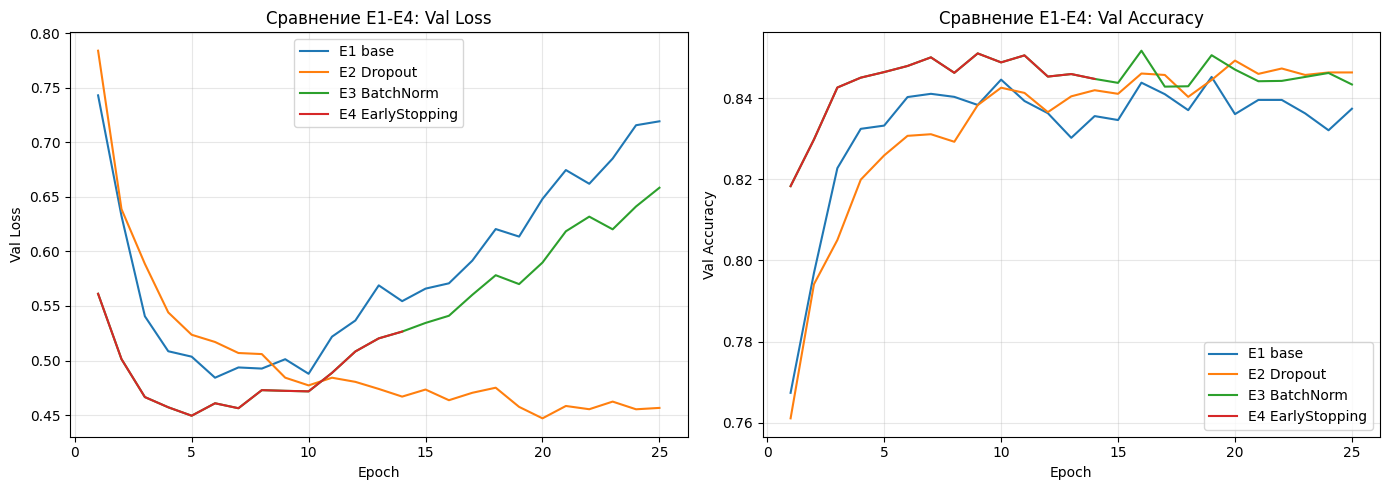

Saved: artifacts/figures/curves_comparison_A.png


In [15]:
# --- Сравнение E1-E4 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, hist in [('E1 base', hist_e1), ('E2 Dropout', hist_e2),
                     ('E3 BatchNorm', hist_e3), ('E4 EarlyStopping', hist_e4)]:
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['val_loss'], label=label)
    axes[1].plot(ep, hist['val_acc'], label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Сравнение E1-E4: Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Сравнение E1-E4: Val Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/curves_comparison_A.png', dpi=150)
plt.show()
print("Saved: artifacts/figures/curves_comparison_A.png")


## 8. Сохранение артефактов


In [16]:
os.makedirs('artifacts/figures', exist_ok=True)
e4_reg = results['E4']['regularizer']

# --- runs.csv ---
fields = ['experiment_id','dataset','seed','model_summary','optimizer',
          'lr','momentum','weight_decay','epochs_trained','best_val_accuracy','best_val_loss']

rows = [
    dict(experiment_id='E1', dataset=DATASET_NAME, seed=SEED,
         model_summary='[512,256] ReLU, no reg', optimizer='Adam',
         lr=LR, momentum='', weight_decay=0, epochs_trained=results['E1']['epochs'],
         best_val_accuracy=f"{results['E1']['best_val_acc']:.4f}",
         best_val_loss=f"{results['E1']['best_val_loss']:.4f}"),
    dict(experiment_id='E2', dataset=DATASET_NAME, seed=SEED,
         model_summary='[512,256] ReLU + Dropout(0.3)', optimizer='Adam',
         lr=LR, momentum='', weight_decay=0, epochs_trained=results['E2']['epochs'],
         best_val_accuracy=f"{results['E2']['best_val_acc']:.4f}",
         best_val_loss=f"{results['E2']['best_val_loss']:.4f}"),
    dict(experiment_id='E3', dataset=DATASET_NAME, seed=SEED,
         model_summary='[512,256] ReLU + BatchNorm', optimizer='Adam',
         lr=LR, momentum='', weight_decay=0, epochs_trained=results['E3']['epochs'],
         best_val_accuracy=f"{results['E3']['best_val_acc']:.4f}",
         best_val_loss=f"{results['E3']['best_val_loss']:.4f}"),
    dict(experiment_id='E4', dataset=DATASET_NAME, seed=SEED,
         model_summary=f'[512,256] ReLU + {e4_reg} + EarlyStopping(p=5)', optimizer='Adam',
         lr=LR, momentum='', weight_decay=0, epochs_trained=results['E4']['epochs'],
         best_val_accuracy=f"{results['E4']['best_val_acc']:.4f}",
         best_val_loss=f"{results['E4']['best_val_loss']:.4f}"),
    dict(experiment_id='O1', dataset=DATASET_NAME, seed=SEED,
         model_summary=f'[512,256] ReLU + {e4_reg}', optimizer='Adam',
         lr=0.1, momentum='', weight_decay=0, epochs_trained=results['O1']['epochs'],
         best_val_accuracy=f"{results['O1']['best_val_acc']:.4f}",
         best_val_loss=f"{results['O1']['best_val_loss']:.4f}"),
    dict(experiment_id='O2', dataset=DATASET_NAME, seed=SEED,
         model_summary=f'[512,256] ReLU + {e4_reg}', optimizer='Adam',
         lr=1e-6, momentum='', weight_decay=0, epochs_trained=results['O2']['epochs'],
         best_val_accuracy=f"{results['O2']['best_val_acc']:.4f}",
         best_val_loss=f"{results['O2']['best_val_loss']:.4f}"),
    dict(experiment_id='O3', dataset=DATASET_NAME, seed=SEED,
         model_summary=f'[512,256] ReLU + {e4_reg}', optimizer='SGD',
         lr=0.01, momentum=0.9, weight_decay=1e-4, epochs_trained=results['O3']['epochs'],
         best_val_accuracy=f"{results['O3']['best_val_acc']:.4f}",
         best_val_loss=f"{results['O3']['best_val_loss']:.4f}"),
]

with open('artifacts/runs.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fields)
    w.writeheader()
    w.writerows(rows)
print("Saved: artifacts/runs.csv")

# --- best_model.pt ---
torch.save(state_e4, 'artifacts/best_model.pt')
print("Saved: artifacts/best_model.pt")

# --- best_config.json ---
config = {
    'experiment': 'E4', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_class': results['E4']['model_class'],
    'hidden_dims': [512, 256], 'activation': 'ReLU',
    'regularization': e4_reg,
    'dropout_p': 0.3 if e4_reg == 'Dropout' else None,
    'optimizer': 'Adam', 'lr': LR, 'batch_size': BATCH_SIZE,
    'max_epochs': 50, 'early_stopping': True, 'patience': 5,
    'epochs_trained': results['E4']['epochs'],
    'best_val_accuracy': results['E4']['best_val_acc'],
    'test_accuracy': test_acc
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("Saved: artifacts/best_config.json")

print("\n=== Все артефакты сохранены ===")


Saved: artifacts/runs.csv
Saved: artifacts/best_model.pt
Saved: artifacts/best_config.json

=== Все артефакты сохранены ===


## 9. Сводная таблица


In [17]:
print(f"{'Exp':<5} {'Opt':<6} {'LR':<10} {'Ep':<6} {'Val Acc':<10} {'Val Loss':<10}")
print("-" * 52)
for r in rows:
    print(f"{r['experiment_id']:<5} {r['optimizer']:<6} {str(r['lr']):<10} "
          f"{r['epochs_trained']:<6} {r['best_val_accuracy']:<10} {r['best_val_loss']:<10}")
print(f"\nЛучшая модель: E4 | Test Accuracy: {test_acc:.4f}")


Exp   Opt    LR         Ep     Val Acc    Val Loss  
----------------------------------------------------
E1    Adam   0.001      25     0.8453     0.4843    
E2    Adam   0.001      25     0.8493     0.4470    
E3    Adam   0.001      25     0.8518     0.4494    
E4    Adam   0.001      14     0.8511     0.4494    
O1    Adam   0.1        8      0.8067     0.6075    
O2    Adam   1e-06      8      0.4320     2.8109    
O3    SGD    0.01       15     0.8494     0.4523    

Лучшая модель: E4 | Test Accuracy: 0.8480
